In [37]:
# IMDB Dataset을 이용해서 감성분류를 해 보아요!
# 영어로 되어 있는 리뷰를 토큰으로 분리
# vocabulary를 생성한 후 이를 이용해서 리뷰를 숫자의 시퀀스로 변경
# label로는 각 리뷰가 긍정의 리뷰면 1, 부정의 리뷰면 0으로 제공
# num_words는 내가 사용할 vocabulary안의 단어수

from tensorflow.keras.datasets import imdb

(x_data_train, y_data_train), (x_data_test, y_data_test) = \
imdb.load_data(num_words=500)

In [38]:
print(x_data_train.shape)  # (25000,)
print(x_data_test.shape)  # (25000,)
print(y_data_train.shape) # (25000,)
# print(y_data_train[:5])  # [1 0 0 1 0]

# print(x_data_train[0])  # python의 list -> 리뷰 1개


(25000,)
(25000,)
(25000,)


[218 189 141 550 147  43 123 562 233 130]
238.71364
178.0


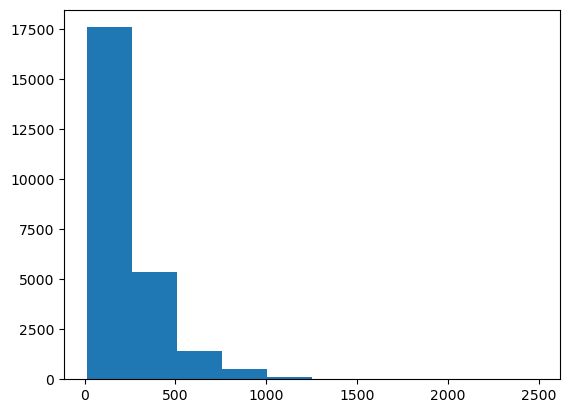

In [39]:
# 이런 Review 데이터를 Model안에 집어넣어서 연산을 수행하려면
# 데이터의 길이가 같아야 해요. (shape이 같아야 해요!)
# 각 review마다 길이가 다른데 어떻게 리뷰의 길이를 똑같이 만드나요?
# 가장 길이가 긴 리뷰의 길이로 전체 리뷰들의 길이를 늘려요!  => 공간의 낭비
# 적절한 길이로 전체 리뷰들의 길이를 제한 => CNN에서 이미지 크기 고정시키듯이
# => 어떤 리뷰들은 조금 짤릴꺼구요, 어떤 리뷰들은 길이가 늘어날꺼예요!
import numpy as np
import matplotlib.pyplot as plt

# 각 Review에 대한 길이를 구해서 ndarray에 저장
lengths = np.array([len(x) for x in x_data_train])
print(lengths[:10])

print(np.mean(lengths))  # 238.71364
print(np.median(lengths))  # 178

plt.hist(lengths)
plt.show()

In [40]:
# 평균, 중앙값, histogram을 구해봤더니..
# 대략 100~150개의 token으로 이루어진 review들이 많다는걸 확인할 수 있었어요!
# 그래서 token 100개로 모든 review의 길이를 조절!
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_data_train_seq = pad_sequences(x_data_train,
                                maxlen=100)
# 모든 review에 대한 길이가 token 100개 짜리고 맞춰지게 되요!
print(x_data_train_seq.shape)  # (25000, 100) 
# 기본적으로 padding처리는 짧은 길이는 앞쪽에 0(padding)을 추가
# 길이가 긴 review(길이가 긴 데이터)는 앞쪽 데이터를 짤라요!

(25000, 100)


In [41]:
# 데이터가 준비되었으니 이제 모델을 구성해 보아요!
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential()
model.add(SimpleRNN(units=8,
                    activation='tanh',
                    input_shape=(100,500)))
model.add(Dense(units=1,
                activation='sigmoid'))

In [42]:
print(x_data_train_seq[0])
# 어떻게 하면 각 token에 대한 값들이 볼륨을 가지지 않고 특정 category를 표현하도록
# 할 수 있을까요? => one-hot encoding
# one-hot으로 바꾸면 카테고리의 개수는 => 500

[  2  33   6  22  12 215  28  77  52   5  14 407  16  82   2   8   4 107
 117   2  15 256   4   2   7   2   5   2  36  71  43   2 476  26 400 317
  46   7   4   2   2  13 104  88   4 381  15 297  98  32   2  56  26 141
   6 194   2  18   4 226  22  21 134 476  26 480   5 144  30   2  18  51
  36  28 224  92  25 104   4 226  65  16  38   2  88  12  16 283   5  16
   2 113 103  32  15  16   2  19 178  32]


In [43]:
# 입력값으로 token에 대한 one-hot encoding값을 사용해야 되기 때문에
# one-hot encoding으로 각 review가 가지는 token들을 변환
from tensorflow.keras.utils import to_categorical

x_data_train_onehot = to_categorical(x_data_train_seq,
                                     num_classes=500)
print(x_data_train_onehot.shape) # (25000, 100, 500)

# (sample의 개수, token의 개수 = timestep, feature -> 토큰을 표현하는 데이터값)
# 공간의 낭비가 생겨요 -> one-hot encoding을 사용해서 그래요. 

(25000, 100, 500)


In [6]:
%reset -f

import numpy as np
import datetime
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import TensorBoard

In [7]:
# Data Loading

(x_data_train, y_data_train), (x_data_test, y_data_test) = \
imdb.load_data(num_words=500)

x_data_train, x_data_val, y_data_train, y_data_val = \
train_test_split(x_data_train,
                 y_data_train,
                 test_size=0.2,
                 stratify=y_data_train)

# padding처리 -> 길이를 100으로 변경
x_data_train_seq = pad_sequences(x_data_train,
                                 maxlen=100)
x_data_val_seq = pad_sequences(x_data_val,
                               maxlen=100)

# # one-hot 처리 -> class개수는 500개
# 이 형태의 구현은 메모리 부족을 야기시킬 수 있어요!
# x_data_train_onehot = to_categorical(x_data_train_seq,
#                                      num_classes=500)
# x_data_val_onehot = to_categorical(x_data_train_seq,
#                                      num_classes=500)

# Model
model = Sequential()
model.add(Lambda(lambda x: tf.one_hot(tf.cast(x, tf.int32), 500),
                 input_shape=(100,)))
model.add(SimpleRNN(units=8,
                    activation='tanh'))
model.add(Dense(units=1,
                activation='sigmoid'))
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

es_cb = EarlyStopping(monitor='val_loss',
                      patience=5,
                      restore_best_weights=True,
                      verbose=1)
cp_cb = ModelCheckpoint(filepath='./simpleRNN-model.weights.h5',
                        monitor='val_loss',
                        save_best_only=True,
                        save_weights_only=True,
                        verbose=1)
log_dir = './logs/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tb_cb = TensorBoard(log_dir=log_dir,
                    histogram_freq=1)



/home/moon9342/anaconda3/envs/notion_env/lib/python3.10/site-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:

# 학습을 진행해 보아요!
# tensorflow 2.16, CUDA 12.3에서는 오류! 메모리 오류
# tensorflow 2.13, CUDA 11.8에서는 동작!
model.fit(x_data_train_seq,
          y_data_train,
          epochs=100,
          batch_size=64,
          validation_data=(x_data_val_seq, y_data_val),
          callbacks=[es_cb, cp_cb, tb_cb],
          verbose=1)

Epoch 1/100


I0000 00:00:1751861714.494757    3314 service.cc:145] XLA service 0x7fc4d8018330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751861714.494844    3314 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2025-07-07 13:15:14.526755: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-07-07 13:15:14.665783: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8900


  1/313 ━━━━━━━━━━━━━━━━━━━━ 7:17 1s/step - accuracy: 0.5000 - loss: 0.7049

I0000 00:00:1751861715.064814    3314 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6037 - loss: 0.6624
Epoch 1: val_loss improved from inf to 0.59701, saving model to ./simpleRNN-model.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6039 - loss: 0.6623 - val_accuracy: 0.6890 - val_loss: 0.5970
Epoch 2/100
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7459 - loss: 0.5486
Epoch 2: val_loss improved from 0.59701 to 0.49949, saving model to ./simpleRNN-model.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7460 - loss: 0.5484 - val_accuracy: 0.7660 - val_loss: 0.4995
Epoch 3/100
190/313 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7781 - loss: 0.4822
Epoch 3: val_loss improved from 0.49949 to 0.47067, saving model to ./simpleRNN-model.weights.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7795 - loss: 0.4799 - val_accuracy: 0.7796 - val_loss: 0.4707
Epoch 4/100
312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7994 - loss: 0.4477
Epoch 4: val_loss i

In [9]:
x_data_test_seq = pad_sequences(x_data_test, 
                                maxlen=100)
result = model.evaluate(x_data_test_seq, y_data_test)
print(result)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7862 - loss: 0.4565 
[0.455381840467453, 0.7866799831390381]
